In [1]:
from tensorflow.keras import backend as K
K.clear_session()

In [2]:
!pip install rarfile

In [3]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=1uh58eeyRUqagxTSlnPyVDaVvoKYIuC95'
#https://drive.google.com/file/d/1oRV8hg2oFALfyKWKm30YK0vJNxDisl_h/view?usp=drive_link
output_rar = '/content/Enhanced_Leguminosae_3C_Dataset.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From: https://drive.google.com/uc?id=1uh58eeyRUqagxTSlnPyVDaVvoKYIuC95
To: /content/Enhanced_Leguminosae_3C_Dataset.rar
100%|██████████| 14.8M/14.8M [00:00<00:00, 94.9MB/s]


In [4]:
# Path to the extracted dataset folder

dataset = '/content/Enhanced_Leguminosae_3C_Dataset'

image.png

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add, GlobalAveragePooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Define the CNN architecture
input_shape = (112, 112, 3)
num_classes = 4
# Input
inputs = layers.Input(shape=input_shape)
# LLF Net#1
a1 = layers.Conv2D(64, (5, 5), strides=(1, 1), activation='relu', padding='same')(inputs)
b1 = layers.Conv2D(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(a1)
c1 = layers.BatchNormalization()(b1)
MPa1 = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(c1)
#Block1
MP33= MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(MPa1)
Path1=layers.Conv2D(32, (1, 1), strides=(1, 1), activation='relu', padding='same')(MP33)
Path2=layers.Conv2D(16, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
Path2=layers.Conv2D(32, (5, 5), strides=(1, 1), activation='relu', padding='same')(Path2)
Path3=layers.Conv2D(96, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
Path3=layers.Conv2D(128, (3, 3), strides=(1, 1), activation='relu', padding='same')(Path3)
Path4=layers.Conv2D(64, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
conc1 = layers.Concatenate()([Path1, Path2, Path3, Path4])
MPa1 = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(conc1)
#Block2
MP33= MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(MPa1)
Path1=layers.Conv2D(64, (1, 1), strides=(1, 1), activation='relu', padding='same')(MP33)
Path2=layers.Conv2D(64, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
Path2=layers.Conv2D(96, (5, 5), strides=(1, 1), activation='relu', padding='same')(Path2)
Path3=layers.Conv2D(128, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
Path3=layers.Conv2D(192, (3, 3), strides=(1, 1), activation='relu', padding='same')(Path3)
Path4=layers.Conv2D(128, (1, 1), strides=(1, 1), activation='relu', padding='same')(MPa1)
conc1 = layers.Concatenate()([Path1, Path2, Path3, Path4])
MPa1 = layers.MaxPooling2D(pool_size=(5, 5), strides=(2, 2), padding='same')(conc1)
# Fully Connected Layer
# Flattening before fully connected layer
FC1= layers.Flatten()(MPa1)
# Fully Connected Layer
FC1 = layers.Dense(1024, activation='relu')(FC1)
outputs = layers.Dense(num_classes, activation='relu')(FC1)
# Create the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 112, 112, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 112, 112, 64)   │          4,864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 56, 56, 64)     │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 56, 56, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 28, 28, 64)     │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 28, 28, 64)     │              0 │ max_pooling2d[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 28, 28, 16)     │          1,040 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 28, 28, 96)     │          6,240 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 32)     │          2,080 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 28, 28, 32)     │         12,832 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 28, 28, 128)    │        110,720 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 28, 28, 64)     │          4,160 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 28, 28, 256)    │              0 │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d_4[0][0],        │
│                           │                        │                │ conv2d_6[0][0],        │
│                           │                        │                │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 14, 14, 256)    │              0 │ concatenate[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 14, 14, 256)    │              0 │ max_pooling2d_2[0][0]  │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)    

 Total params: 24,742,484 (94.39 MB)

 Trainable params: 24,742,356 (94.38 MB)

 Non-trainable params: 128 (512.00 B)

Found 621 images belonging to 4 classes.
Found 87 images belonging to 4 classes.
Found 181 images belonging to 4 classes.
Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 597ms/step - accuracy: 0.2473 - loss: 2.2816 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 2/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2119 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 3/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2547 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 4/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.2506 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 5/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.2624 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 6/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2192 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 7/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2384 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 1.3863
Epoch 8/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2324 - loss: 1.3863 - val_accuracy: 0.2414 - val_loss: 

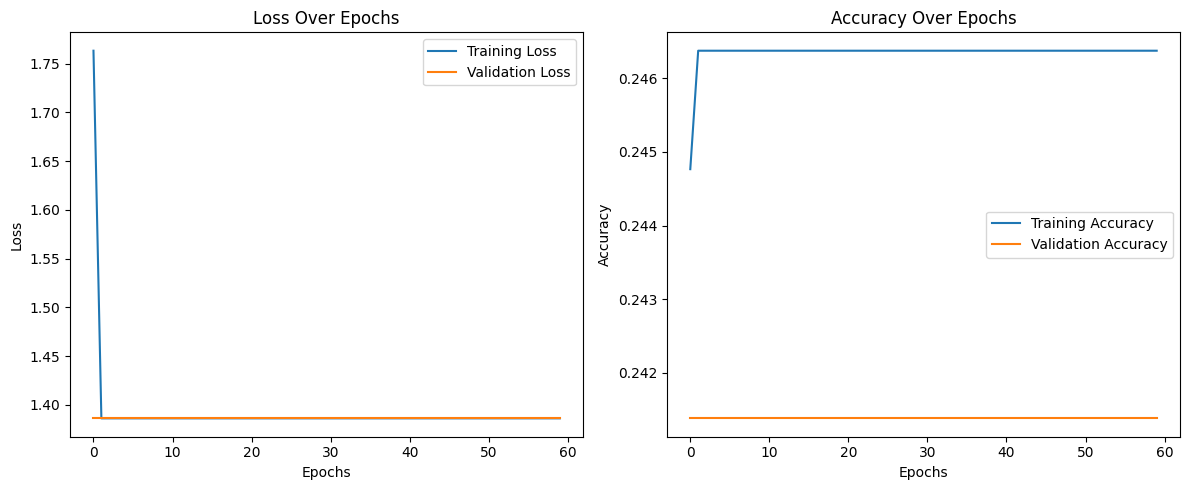

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 377ms/step

Performance on Test Data [Using Model_2-swish]
Precision: 0.06181130002136687
Recall: 0.24861878453038674
F1 Score: 0.09900748056519826
Accuracy: 0.24861878453038674
Confusion Matrix:
                      Acacia_Modesta  Albizia_Lebbeck  Bauhinia_Variegatav  \
Acacia_Modesta                   45                0                    0   
Albizia_Lebbeck                  43                0                    0   
Bauhinia_Variegatav              45                0                    0   
Unknown                          48                0                    0   

                     Unknown  
Acacia_Modesta             0  
Albizia_Lebbeck            0  
Bauhinia_Variegatav        0  
Unknown                    0  


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add,
    GlobalAveragePooling2D, Flatten, Dense
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Directory for the dataset
data_dir = dataset

# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(112, 112),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(112, 112),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(112, 112),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=60, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['Acacia_Modesta', 'Albizia_Lebbeck', 'Bauhinia_Variegatav', 'Unknown'], title="Performance on Test Data [Using Model_2-swish]")
